EDA FOR AMIR Benston

# This notebook will set out to first investigate patterns in perpetrator and victim race combinations for all shootings recorded by NYPD between the years 2006-2024, specifically whether victims tend to share the same race as the perpetrator and how evenly distributed vicim races are across different perpetrator groups.

In [364]:
import pandas as pd

# allows us to use the pandas package in python which we will use for data analysis and manipulation

import matplotlib.pyplot as plt 

# allows us to use the matplotlibs pyplot submodule in order to get a matlab like interface; which we will use for data visualization

In [365]:
shootings = pd.read_csv('../data/processed/clean_data.csv')

# loads the data from clean_data.csv into a pandas dataframe under the variable name shootings

In [366]:
shootings.head()

# displays the first 5 rows of the shootings dataframe


,Unnamed: 0,incident_key,occur_date,occur_time,boro,precinct,jurisdiction_code,statistical_murder_flag,perp_age_group,perp_sex,...,:created_at,:updated_at,:@computed_region_yeji_bk3q,:@computed_region_92fq_4b7q,:@computed_region_sbqj_enih,:@computed_region_efsh_h5xi,:@computed_region_f5dn_yrer,location_desc,loc_of_occur_desc,loc_classfctn_desc
0,0,209281500,2020-02-08T00:00:00.000,12:13:00,QUEENS,115,0.0,True,25-44,M,...,2024-04-23T13:36:19.239Z,2024-04-23T13:36:30.560Z,3.0,21.0,73.0,14510.0,65.0,NaN,NaN,NaN
1,1,209281497,2020-02-08T00:00:00.000,02:20:00,BROOKLYN,76,0.0,True,25-44,M,...,2024-04-23T13:36:19.239Z,2024-04-23T13:36:30.560Z,2.0,7.0,48.0,13514.0,14.0,NaN,NaN,NaN
2,2,209281498,2020-02-07T00:00:00.000,22:50:00,BROOKLYN,75,0.0,False,25-44,M,...,2024-04-23T13:36:19.239Z,2024-04-23T13:36:30.560Z,2.0,37.0,47.0,17214.0,45.0,NaN,NaN,NaN
3,3,209099251,2020-02-05T00:00:00.000,04:02:00,QUEENS,101,0.0,False,NaN,NaN,...,2024-04-23T13:36:19.239Z,2024-04-23T13:36:30.560Z,3.0,47.0,59.0,20529.0,51.0,MULTI DWELL - APT BUILD,NaN,NaN
4,4,209098666,2020-02-05T00:00:00.000,23:13:00,MANHATTAN,34,0.0,False,18-24,M,...,2024-04-23T13:36:19.239Z,2024-04-23T13:36:30.560Z,4.0,39.0,22.0,13098.0,47.0,MULTI DWELL - APT BUILD,NaN,NaN


In [367]:
shootings.tail()

# displays the last 5 rows of the dataframe

,Unnamed: 0,incident_key,occur_date,occur_time,boro,precinct,jurisdiction_code,statistical_murder_flag,perp_age_group,perp_sex,...,:created_at,:updated_at,:@computed_region_yeji_bk3q,:@computed_region_92fq_4b7q,:@computed_region_sbqj_enih,:@computed_region_efsh_h5xi,:@computed_region_f5dn_yrer,location_desc,loc_of_occur_desc,loc_classfctn_desc
28995,995,240338259,2022-02-09T00:00:00.000,00:45:00,BROOKLYN,75,0.0,True,(null),(null),...,2024-04-23T13:36:19.239Z,2024-04-23T13:36:30.560Z,2.0,37.0,47.0,17215.0,45.0,PVT HOUSE,OUTSIDE,STREET
28996,996,240379307,2022-02-09T00:00:00.000,13:33:00,BROOKLYN,90,2.0,False,(null),(null),...,2024-04-23T13:36:19.239Z,2024-04-23T13:36:30.560Z,2.0,30.0,56.0,17213.0,36.0,MULTI DWELL - PUBLIC HOUS,INSIDE,HOUSING
28997,997,240321242,2022-02-08T00:00:00.000,00:30:00,BRONX,48,0.0,False,(null),(null),...,2024-04-23T13:36:19.239Z,2024-04-23T13:36:30.560Z,5.0,43.0,31.0,11269.0,35.0,(null),OUTSIDE,STREET
28998,998,240321668,2022-02-08T00:00:00.000,20:02:00,BROOKLYN,69,0.0,False,25-44,M,...,2024-04-23T13:36:19.239Z,2024-04-23T13:36:30.560Z,2.0,8.0,42.0,13827.0,5.0,(null),OUTSIDE,STREET
28999,999,240321668,2022-02-08T00:00:00.000,20:02:00,BROOKLYN,69,0.0,False,18-24,M,...,2024-04-23T13:36:19.239Z,2024-04-23T13:36:30.560Z,2.0,8.0,42.0,13827.0,5.0,(null),OUTSIDE,STREET


In [368]:
shootings.info()

# prints a full summary of dataframe including total number of rows and columns, non-null count, data type and name for each column etc 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29000 entries, 0 to 28999
Data columns (total 31 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Unnamed: 0                   29000 non-null  int64  
 1   incident_key                 29000 non-null  int64  
 2   occur_date                   29000 non-null  object 
 3   occur_time                   29000 non-null  object 
 4   boro                         29000 non-null  object 
 5   precinct                     29000 non-null  int64  
 6   jurisdiction_code            28998 non-null  float64
 7   statistical_murder_flag      29000 non-null  bool   
 8   perp_age_group               19703 non-null  object 
 9   perp_sex                     19704 non-null  object 
 10  perp_race                    19704 non-null  object 
 11  vic_age_group                29000 non-null  object 
 12  vic_sex                      29000 non-null  object 
 13  vic_race        

In [369]:
shootings.describe()

# give us descriptive statistics for each numeric column in the dataframe

,Unnamed: 0,incident_key,precinct,jurisdiction_code,latitude,longitude,:@computed_region_yeji_bk3q,:@computed_region_92fq_4b7q,:@computed_region_sbqj_enih,:@computed_region_efsh_h5xi,:@computed_region_f5dn_yrer
count,29000.000000,2.900000e+04,29000.000000,28998.000000,28903.000000,28903.000000,28903.000000,28903.000000,28903.000000,28862.000000,28903.000000
mean,499.500000,1.369615e+08,65.207207,0.318263,40.739519,-73.908989,3.280525,29.829845,40.424489,14713.522625,38.665433
std,288.679968,8.149749e+07,27.373641,0.729037,0.087726,0.065619,1.320795,13.940465,16.924575,3784.021785,20.280171
min,0.000000,1.681403e+07,1.000000,0.000000,40.511586,-74.249303,1.000000,1.000000,1.000000,10090.000000,1.000000
25%,249.750000,7.175669e+07,44.000000,0.000000,40.669045,-73.942736,2.000000,17.000000,27.000000,11605.000000,18.000000
50%,499.500000,1.373719e+08,67.000000,0.000000,40.703146,-73.914762,3.000000,31.000000,40.000000,13512.000000,42.000000
75%,749.250000,2.153030e+08,81.000000,0.000000,40.825389,-73.882660,5.000000,42.000000,52.000000,17215.000000,55.000000
max,999.000000,2.994625e+08,123.000000,2.000000,40.910818,-73.702046,5.000000,51.000000,77.000000,24894.000000,71.000000


In [370]:
shootings['perp_race'].value_counts(dropna=False)


# give us the value counts for each unique value in the perp_race column dropna=False overrides not including null (missing) values



perp_race
BLACK                             11878
NaN                                9296
WHITE HISPANIC                     2583
UNKNOWN                            1665
(null)                             1628
BLACK HISPANIC                     1474
WHITE                               294
ASIAN / PACIFIC ISLANDER            180
AMERICAN INDIAN/ALASKAN NATIVE        2
Name: count, dtype: int64

In [371]:
shootings['vic_race'].value_counts(dropna=False)

# give us the value counts for each unique value in the vic_race column dropna=False overrides not including null (missing) values

vic_race
BLACK                             20486
WHITE HISPANIC                     4334
BLACK HISPANIC                     2914
WHITE                               718
ASIAN / PACIFIC ISLANDER            464
UNKNOWN                              71
AMERICAN INDIAN/ALASKAN NATIVE       13
Name: count, dtype: int64

In [372]:
shootings['perp_race'] = shootings['perp_race'].replace('(null)', pd.NA)

# replaces null strings with true pandas null values NaN

shootings['perp_race'] = shootings['perp_race'].fillna('UNKNOWN')

# coverts our null values to UNKNOWN and combines them with the values already listed as unknown in the dataframe

In [373]:
# perp_race and vic_race combination table 



race_count = shootings.groupby(['perp_race', 'vic_race']).size().reset_index(name='count')

# groupby groups the different combinations of (perp_race and vic_race together) into distinct groups 
# .size tells us the total count for each group of (perp_race and vic_race) combination and put this into a series
#.reset_index(name='count') turns this grouped series back into a regular df with 3 columns perp_race, vic_race and count

race_count['pct_perp_race'] = (race_count['count'] / race_count.groupby('perp_race')['count'].transform('sum') * 100).round(2)

# creates a new column pct_perp_race which will sit next to count and show the percent of shootings committed by that race category each row represents
# race_count['count'] our numerator gives the total shootings for that specfic rows (perp_race, vic_race) combination
# race_count.groupby('perp_race')['count'].transform('sum') our denominator gives us the total count of shootings committed by that rows unique prep_race category transform keeps the shape of the original df
# *100 multiplies each rows fraction by 100 to represent pct_perp_race as a percent
# .round(2) rounds to two decimal places 

race_count = race_count.sort_values(['perp_race', 'count'], ascending=[True, False])

# .sort_values sorts the rows of race_count using the two selected columns perp_race will be in ascending alphabetical order and the highest counts will show first in descending order

display(race_count)




,perp_race,vic_race,count,pct_perp_race
0,AMERICAN INDIAN/ALASKAN NATIVE,BLACK,2,100.00
1,ASIAN / PACIFIC ISLANDER,ASIAN / PACIFIC ISLANDER,66,36.67
2,ASIAN / PACIFIC ISLANDER,BLACK,61,33.89
5,ASIAN / PACIFIC ISLANDER,WHITE HISPANIC,28,15.56
3,ASIAN / PACIFIC ISLANDER,BLACK HISPANIC,14,7.78
4,ASIAN / PACIFIC ISLANDER,WHITE,11,6.11
8,BLACK,BLACK,9374,78.92
12,BLACK,WHITE HISPANIC,1247,10.50
9,BLACK,BLACK HISPANIC,852,7.17
11,BLACK,WHITE,206,1.73


# The following observations examine patterns in shooter and victim race combinations, specifically whether victims tend to share the race as the perpetrator and how evenly distributed victim races are across perpetrator groups

# For instance in shootings on record where the perpetrator was Asian the race of the victim was more evenly distributed then most other race groups. 37% of victims were also Asian which is the most for Asian perpetrators but represents the lowest percent total of the highest amount of victims for a particular perpetrator group. 34% of victims were Black which is the highest percent total of the second most common victim group for any particular perpetrator group. The combination of these two factors makes Asian prep_race data stand out as more evenly distributed.


# In contrast in shootings where the perpetrator was Black the race of the victim was less evenly distributed than other race groups. 79% percent of the victims were also Black which is the highest percent total of any perp_race vic_race combination. The 2nd highest victim group for this category was White Hispanic with 11% which is the lowest percent total for any 2nd place perp_race vic_race combination in our dataset. The combination of these facts about our data leads me to believe in shootings where the perpetrator was Black the race of the victim was less evenly distributed than other race groups as it relates to our dataset.

# I was also able to ascertain that Black was the only victim group that represented at least 15% of shooting victims for all perp_race categories.

# Last but not least for all perp_race categories besides Asian / Pacific Islander, White Hispanic was the second most evenly distributed in regards to the race of victims. White Hispanic was the most represented victim group in this category 42%; the second lowest most represented victim group for all perpetrator race groups. Next was Black victims 34% and 3rd was Black Hispanic 18%. White Hispanic is the only perpetrator group where at least 3 different victim groups represent 18% of victims indicating more even distribution amongst victims.

# Below I will express the following observations as a 100% stacked column chart showing victim race distribution by perpetrator race

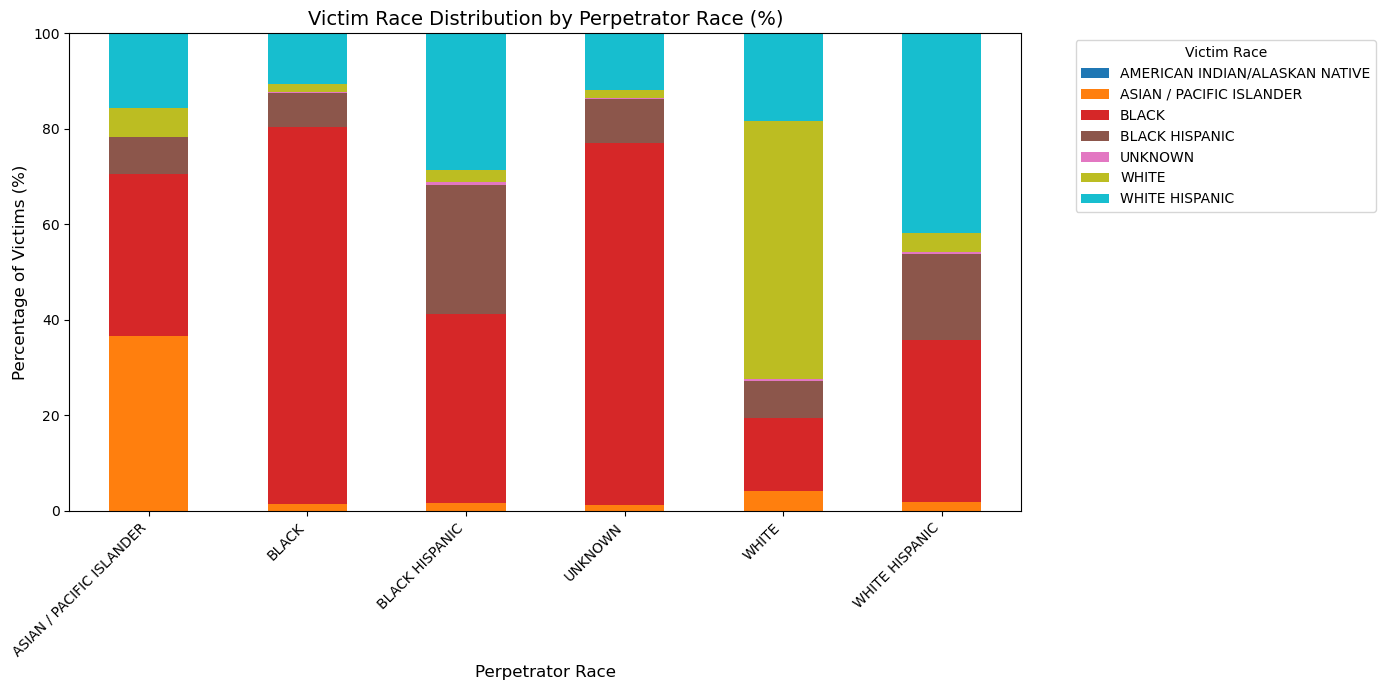

In [374]:

# pivot: perp_race as rows, vic_race as columns, values = pct_perp_race

pivot = race_count.pivot(index='perp_race', columns= 'vic_race', values= 'pct_perp_race').fillna(0)

# .pivot reshapes race_count from long format into wide format
# each unique perp_race becomes a row, each unique vic_race becomes a column
# .fillna(0) fills any missing combinations with 0 since those pairings had no shootings

pivot = pivot.drop(index='AMERICAN INDIAN/ALASKAN NATIVE')

# Removes American Indian/Alaskan Native from the chart since it only accounts for 2 total perpetrators

# 100% stacked column chart showing victim race distribution by perpetrator race

ax = pivot.plot(kind='bar', stacked=True, figsize=(14,7), colormap='tab10')

# kind='bar' produces a vertical bar chart
# stacked=True stacks each vic_race segment on top of one another per perp_race group
# figsize sets the width and height of the chart in inches
# colormap='tab10' assigns a distinct color to each vic_race category

ax.set_title('Victim Race Distribution by Perpetrator Race (%)', fontsize=14)
ax.set_xlabel('Perpetrator Race', fontsize=12)
ax.set_ylabel('Percentage of Victims (%)', fontsize=12)
ax.set_ylim(0,100)
# set_ylim locks the y axis from 0 to 100 since we are plotting percentages
ax.legend(title='Victim Race', bbox_to_anchor=(1.05,1), loc='upper left')
# moves the legend outside the chart so it doesn't block the bars
plt.xticks(rotation=45, ha='right')
# rotation=45 tilts each label 45 degrees diagonally so long labels won't overlap with each and become unreadable
# ha='right' tells matplot to anchor the right edge of each label to it's tick in the x-axis so I can tell which label goes with what bar
plt.tight_layout()
# makes sure nothing inside the gets overlapped
plt.show()

# From the data visualization we can see that Black is the least distrubuted perpretrator group though it should be noted American Indian only counts for two total perpetrators so it was removed from the bar chart. 

# We can also see that Asian, White Hispanic and White are the perpetrator groups with the most distrubution amongst their victims.

# Now I will set out to examine how each individual racial group is represented first amongst all shooting victims on record then all shooting perpetrators on record.

In [375]:
# Table that shows how each individual racial group is represented amoungst all recorded shooting victims

vic_race_count = shootings.groupby(['vic_race']).size().reset_index(name='count')

# groupby groups all shootings by vic_race into distinct groups
# .size tells us the total count for each vic_race category and puts this into a series
# .reset_index(name='count') turns this grouped series back into a regular df with 2 columns vic_race and count

vic_race_count['pct_total_vic'] = (vic_race_count['count'] / vic_race_count['count'].sum() * 100).round(2)

# creates a new column pct_total_vic which sits next to count and shows what percent of all shootings each vic_race category represents
# vic_race_count['count'] the numerator give us the total victim count for that rows particular racial group
# vic_race_count['count'].sum() * 100 the denominator give us the total victim count for every row which includes all racial groups and multiplies our fraction by 100 to convert to a percentage
# .round(2) rounds our pecentage to two decimal places

vic_race_count = vic_race_count.sort_values(['count'], ascending =[False])

# .sort_values sorts the values of count so the highest count will appear first and be listed in decending order
display(vic_race_count)

,vic_race,count,pct_total_vic
2,BLACK,20486,70.64
6,WHITE HISPANIC,4334,14.94
3,BLACK HISPANIC,2914,10.05
5,WHITE,718,2.48
1,ASIAN / PACIFIC ISLANDER,464,1.60
4,UNKNOWN,71,0.24
0,AMERICAN INDIAN/ALASKAN NATIVE,13,0.04


# From this table we are able to see that Black victims account for 71% of all shooting victims which is by far the most of any racial group. 2nd are White Hispanic victims at 15% and 3rd Black Hispanic victims at 10%. These three racial groups represent over 95% of all shooting victims recorded by NYPD from the years 2006-2024. This suggests gun violence in NYC disporpotionally affects Black and Hispanic communities.

In [376]:
# Now I will display the same data as a bar graph where x represents the different racial groups and y will be the percent of total victims that group represents

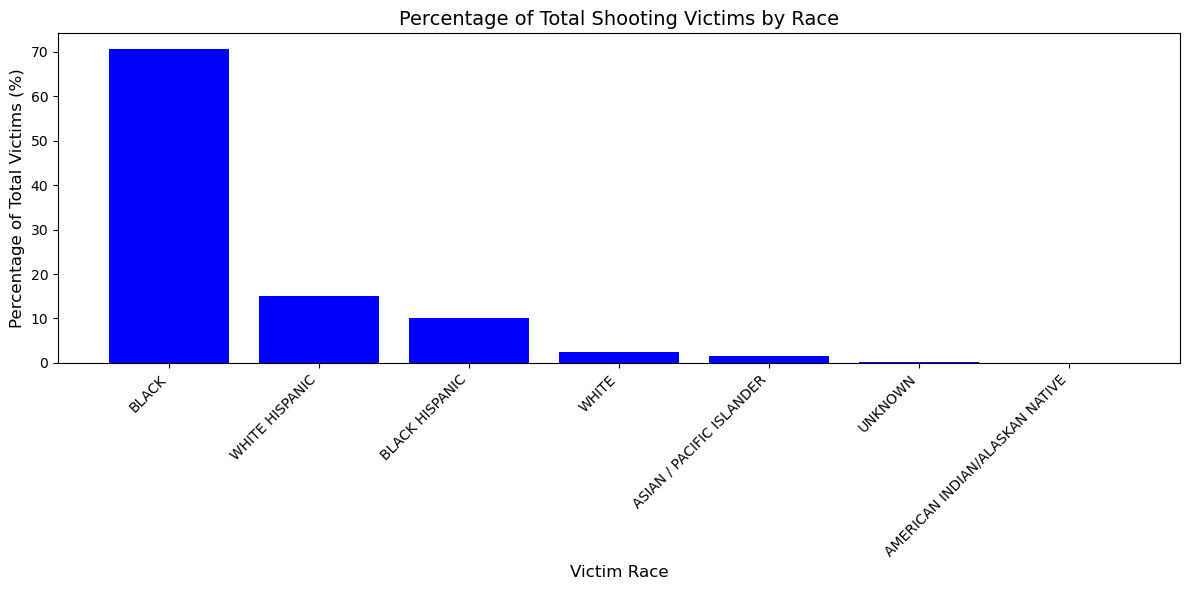

In [377]:
# bar graph 
fig, ax = plt.subplots(figsize=(12, 6))
# fig creates the overall figure object and ax is the axes details we use to build the chart
# figsize sets width and height in inches
ax.bar(vic_race_count['vic_race'], vic_race_count['pct_total_vic'], color='blue')
# ax.bar assigns x values from vic_race and y values from pct_total_vic and the color of the bars will be blue
ax.set_title('Percentage of Total Shooting Victims by Race', fontsize=14)
ax.set_xlabel('Victim Race', fontsize=12)
ax.set_ylabel('Percentage of Total Victims (%)', fontsize=12)
plt.xticks(rotation=45, ha='right')
# rotation=45 tilts each label 45 degrees diagonally so long labels won't overlap with each and become unreadable
# ha='right' tells matplot to anchor the right edge of each label to it's tick in the x-axis so I can tell which label goes with what bar
plt.tight_layout()
# makes sure nothing inside the gets overlapped
plt.show()


# From the bar graph we can easily see that Black victims are by far the most represented victim group and 3 racial groups Black, White Hispanic and Black Hispanic are the only racial groups that represent at least 10% of all shooting victims recorded by NYPD during the years 2006-2024.

Now lastly I will investigate how each racial group is represented amongst all shooting perpetraters recorded by NYPD during the years 2006-2024

In [378]:
# Table that shows how each individual racial group is represented amoungst all recorded shooting perpetrators

perp_race_count = shootings.groupby(['perp_race']).size().reset_index(name='count')

# # groupby groups all shootings by perp_race into distinct groups
# .size tells us the total count for each perp_race category and puts this into a series
# .reset_index(name='count') turns this grouped series back into a regular df with 2 columns perp_race and count

perp_race_count['pct_total_perp'] = (perp_race_count['count'] / perp_race_count['count'].sum() * 100).round(2)

# creates a new column pct_total_perp which sits next to count and shows what percent of all shootings each perp_race category represents
# perp_race_count['count'] the numerator give us the total perp count for that rows particular racial group
# perp_race_count['count'].sum * 100 the denominator give us the total perp count for every row which includes all racial groups and multiplies our fraction by 100 to convert to a percentage
# .round(2) rounds our pecentage to two decimal places

perp_race_count = perp_race_count.sort_values(['count'], ascending =[False])

# .sort_values sorts the values of count so the highest count will appear first and be listed in decending order
display(perp_race_count)

,perp_race,count,pct_total_perp
4,UNKNOWN,12589,43.41
2,BLACK,11878,40.96
6,WHITE HISPANIC,2583,8.91
3,BLACK HISPANIC,1474,5.08
5,WHITE,294,1.01
1,ASIAN / PACIFIC ISLANDER,180,0.62
0,AMERICAN INDIAN/ALASKAN NATIVE,2,0.01


# From the following table above we can see that 43% of shootings recorded by NYPD during the years 2006-2024 had a perpetrator that was Unknown the highest of any group during this timeframe and this likely reflects that for 43% of recorded shootings during this timeframe the perpetrator was never identified. 

# Second was Black perpetrators who made up 41% of all shooting perpetrators. Black is the most overrepresented race group for both shooting victims and perpetrators; the only group to make up at least 40% of both catergories despite only making up 22% of NYC population in 2024 https://www.census.gov/quickfacts/fact/table/newyorkcitynewyork/PST045224. 

Next I will express this same data as bar graph

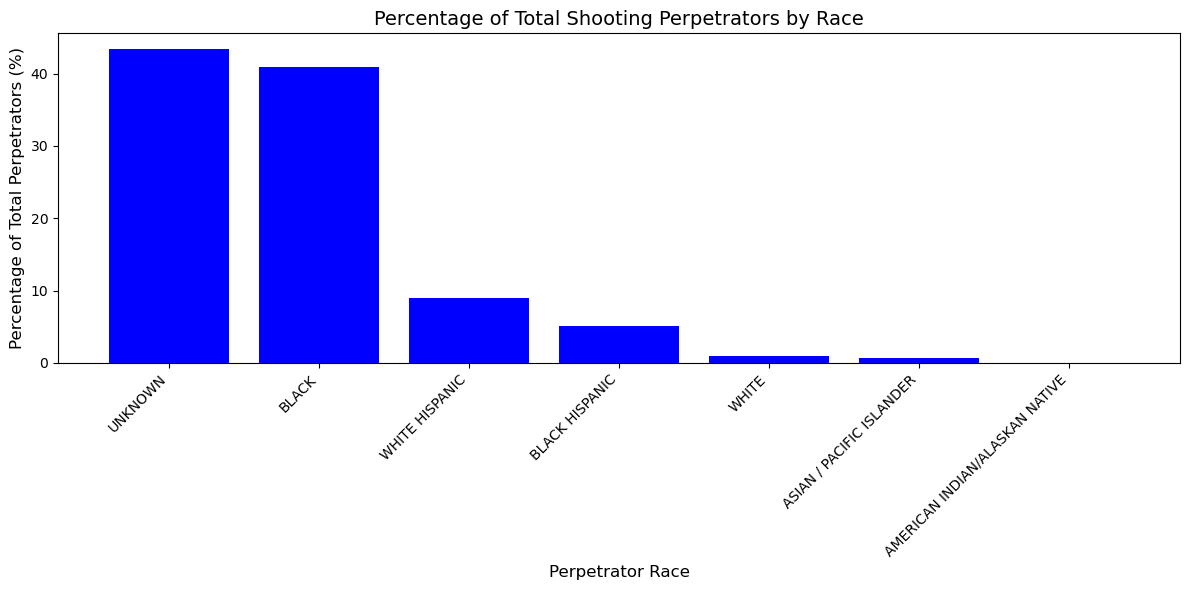

In [379]:
# bar graph 
fig, ax = plt.subplots(figsize=(12, 6))
# fig creates the overall figure object and ax is the axes details we use to build the chart
# figsize sets width and height in inches
ax.bar(perp_race_count['perp_race'], perp_race_count['pct_total_perp'], color='blue')
# ax.bar assigns x values from prep_race and y values from pct_total_perp and the color of the bars will be blue
ax.set_title('Percentage of Total Shooting Perpetrators by Race', fontsize=14)
ax.set_xlabel('Perpetrator Race', fontsize=12)
ax.set_ylabel('Percentage of Total Perpetrators (%)', fontsize=12)
plt.xticks(rotation=45, ha='right')
# rotation=45 tilts each label 45 degrees diagonally so long labels won't overlap with each and become unreadable
# ha='right' tells matplot to anchor the right edge of each label to it's tick in the x-axis so I can tell which label goes with what bar
plt.tight_layout()
# makes sure nothing inside the gets overlapped
plt.show()

# From the bar graph we can see that most shooting perpetrators are classified as unknown and unknown and Black are the only two perpetrator groups that account for 40% of all perpetrators. White Hispanic is the 3rd most represented group and Black Hispanic 4th. American Indian represents so little of recorded shooting perpetrators that it doesn't even register as a bar.

# These findings make me want to explore more about the unknown perpetrators and some possible reasons why so many shooting incidents go without a perpetrator being named and if it's possibly due to police bias in what groups are more likely to be investigated as a potential shooting perpetrator.

# I would also like to explore as it relates to the different racial groups and gender.

# Another thing that stood out that I look forward to investigating in the future is how this data compares to the national data over the same time or overlapping time spans. For instance per this article and the FBI's database https://www.urban.org/2016-analysis/what-data-really-say-about-race-and-homicide in 2014 nationally 82% of White homicide's were committed by other White people. I would like to compare that to NYPD's data for 2014. One thing I should keep in mind is NYPD and the FBI may classify the racial groups differently.

